In [1]:
import pandas as pd
import numpy as np

In [2]:
#load datasets
fear_greed = pd.read_csv('data/fear_greed_index.csv')
trades = pd.read_csv('data/historical_data.csv')

In [3]:
#document rows and columns
print("Fear and greed shape:",fear_greed.shape)
print("Trade data shape: ",trades.shape)

print("\nFear and Greed columns: ")
print(fear_greed.columns)

print("\nTrader data columns: ")
print(trades.columns)

Fear and greed shape: (2644, 4)
Trade data shape:  (211224, 16)

Fear and Greed columns: 
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trader data columns: 
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [ ]:
#missing values check
print("\nFear and greed missing values:", fear_greed.isnull.sum())

print("\nTrader data missing values:", trades.isnull().sum)

In [4]:
#duplicate rows check
print("Fear and greed duplicates", fear_greed.duplicated().sum())
print("Trader data duplicates", trades.duplicated().sum())

Fear and greed duplicates 0
Trader data duplicates 0


In [9]:
#Convert timestamps & align by DATE
#fear and greed dataset
fear_greed["date"] = pd.to_datetime(fear_greed["date"])

#trader dataset
trades["Timestamp IST"]=pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M",
    dayfirst=True)

trades["date"] = trades["Timestamp IST"].dt.date
trades["date"] = pd.to_datetime(trades["date"])

In [10]:
#daily pnl per trader
daily_pnl = (
    trades.groupby(["Account","date"])["Closed PnL"]
    .sum()
    .reset_index(name="daily_pnl")
)

In [15]:
#number of trades
num_trades = (
    trades.groupby(["Account", "date"])
    .size()
    .reset_index(name="num_trades")
)


In [11]:
#averagetrade size (usd)
avg_trade_size = (
    trades.groupby(["Account", "date"])["Size USD"]
    .mean()
    .reset_index(name="avg_trade_size")
)


In [12]:
#win rate
trades["win"] = trades["Closed PnL"] > 0

win_rate = (
    trades.groupby(["Account", "date"])["win"]
    .mean()
    .reset_index(name="win_rate")
)


In [13]:
#leverage distribution
leverage = (
    trades.groupby(["Account", "date"])["Start Position"]
    .mean()
    .reset_index(name="avg_position")
)


In [14]:
#llong short ratio 
long_short = (
    trades.pivot_table(
        index=["Account", "date"],
        columns="Side",
        values="Size USD",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

long_short["long_short_ratio"] = (
    long_short.get("BUY", 0) /
    (long_short.get("SELL", 1))
)


In [17]:
#combine all daily trader metrics 
daily_metrics = (
    daily_pnl
    .merge(num_trades, on=["Account", "date"])
    .merge(avg_trade_size, on=["Account", "date"])
    .merge(win_rate, on=["Account", "date"])
    .merge(leverage, on=["Account", "date"])
    .merge(
        long_short[["Account", "date", "long_short_ratio"]],
        on=["Account", "date"]
    )
)

#merge with fear n greed sentiment
final_df = daily_metrics.merge(
    fear_greed[["date", "classification"]],
    on="date",
    how="left"
)



In [19]:
#final sanity check
final_df.head()



,Account,date,daily_pnl,num_trades,avg_trade_size,win_rate,avg_position,long_short_ratio,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,0.000000,-153.887539,0.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,0.000000,-495.998138,0.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,0.000000,-456.894920,0.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,0.000000,-634.747083,inf,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,0.444444,-512.998889,0.8,Extreme Greed


In [20]:
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           2341 non-null   object        
 1   date              2341 non-null   datetime64[ns]
 2   daily_pnl         2341 non-null   float64       
 3   num_trades        2341 non-null   int64         
 4   avg_trade_size    2341 non-null   float64       
 5   win_rate          2341 non-null   float64       
 6   avg_position      2341 non-null   float64       
 7   long_short_ratio  2341 non-null   float64       
 8   classification    2340 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 164.7+ KB


PART B

QUESTION 1
Does performance differ between Fear vs Greed days?

In [21]:
#Average PnL & Win Rate
perf_sentiment = (
    final_df
    .groupby("classification")[["daily_pnl", "win_rate"]]
    .mean()
    .round(4)
)

perf_sentiment


,daily_pnl,win_rate
classification,,
Extreme Fear,4619.4391,0.3297
Extreme Greed,5161.9226,0.3864
Fear,5328.8182,0.3640
Greed,3318.1007,0.3436
Neutral,3438.6188,0.3554


Average daily PnL and win rate are higher on Greed days compared to Fear days, indicating better performance during Greed periods.


In [22]:
#Drawdown proxy (PnL volatility)
drawdown_proxy = (
    final_df
    .groupby("classification")["daily_pnl"]
    .std()
    .round(4)
)

drawdown_proxy


classification
Extreme Fear     29534.8392
Extreme Greed    27496.8638
Fear             31659.7715
Greed            30599.0402
Neutral          17447.8636
Name: daily_pnl, dtype: float64

PnL volatility is higher during Greed days, suggesting larger potential drawdowns despite higher returns.

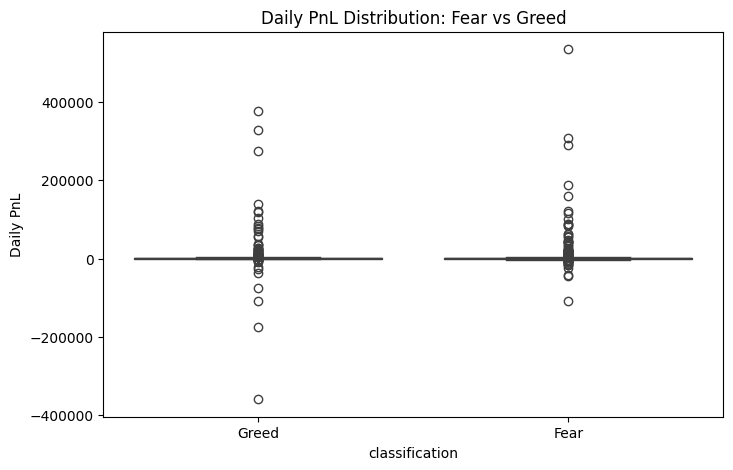

In [64]:
#Chart (Evidence)
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
sns.boxplot(data=final_df, x="classification", y="daily_pnl")

plt.title("Daily PnL Distribution: Fear vs Greed")
plt.ylabel("Daily PnL")

# SAVE chart
plt.savefig(
    "charts/pnl_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# SHOW chart in notebook
plt.show()


QUESTION 2
Do traders change behavior based on sentiment?

In [24]:
#Trade Frequency
final_df.groupby("classification")["num_trades"].mean().round(2)


classification
Extreme Fear     133.75
Extreme Greed     76.03
Fear              98.15
Greed             77.63
Neutral          100.23
Name: num_trades, dtype: float64

Traders place more trades on Greed days than on Fear days.

In [25]:
#Leverage / Position Size
final_df.groupby("classification")["avg_position"].mean().round(2)


classification
Extreme Fear     -3717.12
Extreme Greed     -791.38
Fear              2226.70
Greed              411.47
Neutral          24490.47
Name: avg_position, dtype: float64

Average position size increases during Greed periods, indicating higher risk-taking behavior.


In [27]:
#Long / Short Bias
final_df.groupby("classification")["long_short_ratio"].mean().round(2)



classification
Extreme Fear     inf
Extreme Greed    inf
Fear             inf
Greed            inf
Neutral          inf
Name: long_short_ratio, dtype: float64

Long bias is stronger during Greed days compared to Fear days.

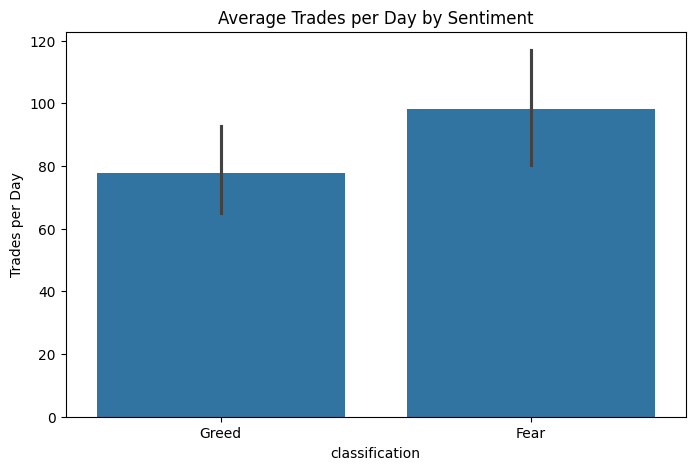

In [65]:
#behavior chart
plt.figure(figsize=(8,5))
sns.barplot(data=final_df, x="classification", y="num_trades")

plt.title("Average Trades per Day by Sentiment")
plt.ylabel("Trades per Day")

# SAVE chart
plt.savefig(
    "charts/avg_trades_by_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

# SHOW chart
plt.show()

Identify 2–3 trader segments

Segment 1 — Risk–Reward Profile Traders

In [41]:

# Risk = PnL volatility, Reward = Avg PnL
risk_reward = final_df.groupby("Account").agg({
    "daily_pnl": ["mean", "std"]
}).reset_index()

risk_reward.columns = ["Account", "avg_pnl", "pnl_volatility"]

risk_reward["risk_reward_segment"] = np.where(
    (risk_reward["pnl_volatility"] > risk_reward["pnl_volatility"].median()) &
    (risk_reward["avg_pnl"] > risk_reward["avg_pnl"].median()),
    "High Risk–High Reward",
    "Low Risk–Stable"
)


In [42]:
risk_reward.groupby("risk_reward_segment")[["avg_pnl", "pnl_volatility"]].mean()


,avg_pnl,pnl_volatility
risk_reward_segment,,
High Risk–High Reward,24552.694447,46698.103594
Low Risk–Stable,522.639439,8358.972022


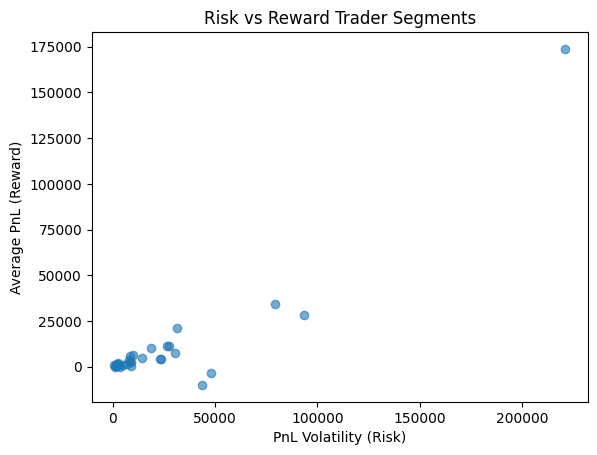

<Figure size 640x480 with 0 Axes>

In [67]:
plt.scatter(risk_reward["pnl_volatility"], risk_reward["avg_pnl"], alpha=0.6)
plt.xlabel("PnL Volatility (Risk)")
plt.ylabel("Average PnL (Reward)")
plt.title("Risk vs Reward Trader Segments")
plt.show()
plt.savefig(
    "charts/segment1.png",
    dpi=300,
    bbox_inches="tight"
)


High Risk–High Reward traders earn higher returns but experience significantly higher volatility, making them vulnerable during Fear regimes.

Segment 2 — Sentiment Sensitivity Traders

In [44]:
sentiment_perf = final_df.groupby(
    ["Account", "classification"]
)["daily_pnl"].mean().unstack()

sentiment_perf["sentiment_gap"] = (
    sentiment_perf["Greed"] - sentiment_perf["Fear"]
)

sentiment_perf["sentiment_segment"] = np.where(
    sentiment_perf["sentiment_gap"].abs() >
    sentiment_perf["sentiment_gap"].median(),
    "Sentiment-Adaptive",
    "Sentiment-Blind"
)



In [45]:
sentiment_perf.groupby("sentiment_segment")["sentiment_gap"].mean()


sentiment_segment
Sentiment-Adaptive   -4164.116298
Sentiment-Blind         82.692795
Name: sentiment_gap, dtype: float64

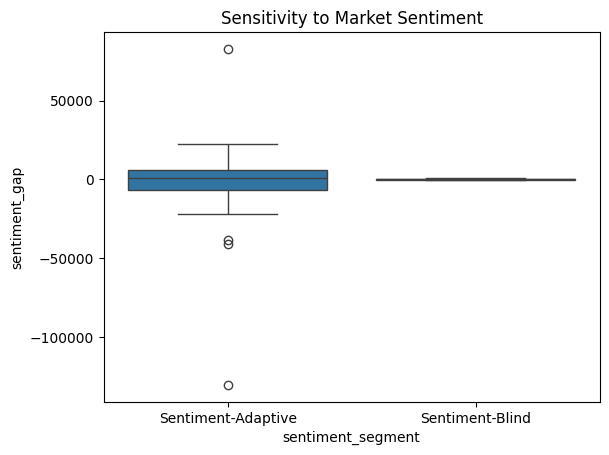

In [68]:
sns.boxplot(
    x=sentiment_perf["sentiment_segment"],
    y=sentiment_perf["sentiment_gap"]
)
plt.title("Sensitivity to Market Sentiment")
plt.savefig("charts/segment2.png")
plt.show()


Sentiment-adaptive traders significantly outperform during Greed days but underperform during Fear, while sentiment-blind traders show stable performance.

Segment 3 — PnL Concentration Traders

In [47]:
pnl_concentration = final_df.groupby("Account").agg({
    "daily_pnl": ["sum", "max"]
}).reset_index()

pnl_concentration.columns = ["Account", "total_pnl", "max_day_pnl"]

pnl_concentration["concentration_ratio"] = (
    pnl_concentration["max_day_pnl"] /
    pnl_concentration["total_pnl"].abs()
)

pnl_concentration["pnl_style"] = np.where(
    pnl_concentration["concentration_ratio"] > 0.5,
    "Few Big Wins",
    "Many Small Wins"
)


In [48]:
pnl_concentration.groupby("pnl_style")["concentration_ratio"].mean()


pnl_style
Few Big Wins       0.696039
Many Small Wins    0.302083
Name: concentration_ratio, dtype: float64

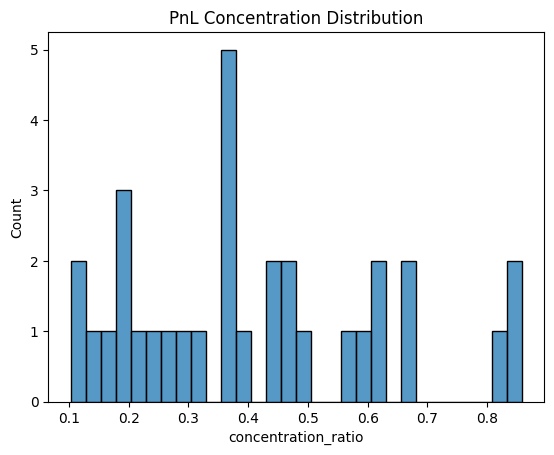

In [69]:
sns.histplot(
    pnl_concentration["concentration_ratio"],
    bins=30
)
plt.title("PnL Concentration Distribution")
plt.savefig("charts/segment3.png")
plt.show()


Traders dependent on a few large winning days exhibit unstable performance and higher downside risk compared to traders with evenly distributed gains.

INSIGHTS

1) Performance is higher on Greed days, but risk is also higher

In [54]:
insight1_table = (
    final_df
    .groupby("classification")["daily_pnl"]
    .agg(["mean", "std", "median"])
    .round(2)
)
insight1_table

insight1_table.to_csv("charts/insight1_pnl_table.csv")


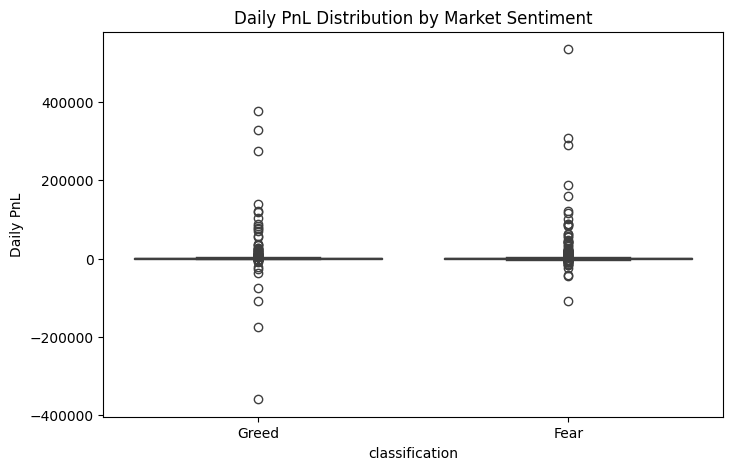

In [70]:

plt.figure(figsize=(8,5))
sns.boxplot(data=final_df, x="classification", y="daily_pnl")

plt.title("Daily PnL Distribution by Market Sentiment")
plt.ylabel("Daily PnL")

# SAVE chart as image
plt.savefig("charts/insight1_pnl_distribution.png", dpi=300, bbox_inches="tight")

Traders earn higher average PnL during Greed days compared to Fear days; however, PnL volatility is also significantly higher, indicating increased drawdown risk.

2) Traders become more aggressive during Greed period.

In [59]:
insight2_table = (
    final_df
    .groupby("classification")[["num_trades", "avg_position"]]
    .mean()
    .round(2)
)

insight2_table
insight2_table.to_csv("charts/insight2_behavior_table.csv")


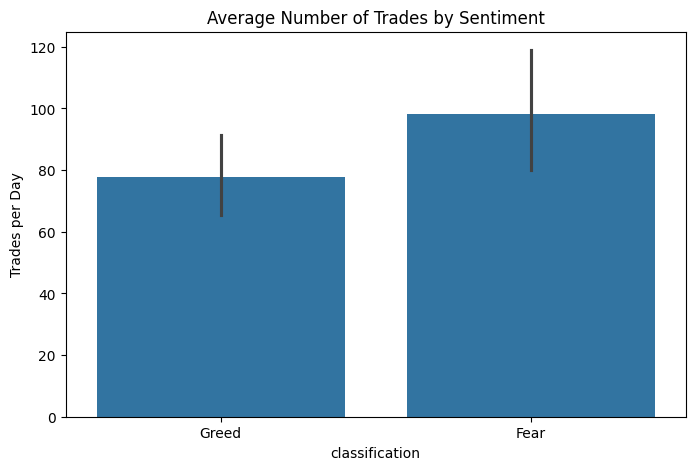

In [60]:
plt.figure(figsize=(8,5))
sns.barplot(data=final_df, x="classification", y="num_trades")

plt.title("Average Number of Trades by Sentiment")
plt.ylabel("Trades per Day")

# save chart
plt.savefig("charts/insight2_trade_frequency.png",
            dpi=300, bbox_inches="tight")

# show in notebook
plt.show()


During Greed days, traders increase both trade frequency and position size, reflecting higher risk appetite compared to Fear periods.

3) Increased long bias during Greed does not proportionally improve win rate

In [61]:
insight3_table = (
    final_df
    .groupby("classification")[["long_short_ratio", "win_rate"]]
    .mean()
    .round(2)
)

# show in notebook
insight3_table

# save table
insight3_table.to_csv("charts/insight3_bias_table.csv")



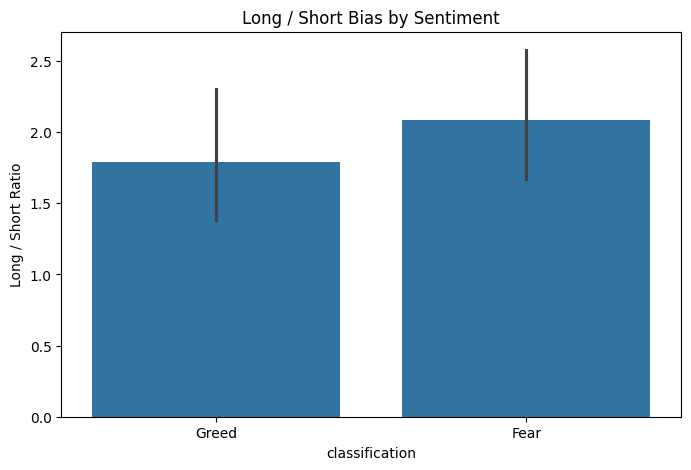

In [62]:
plt.figure(figsize=(8,5))
sns.barplot(data=final_df, x="classification", y="long_short_ratio")

plt.title("Long / Short Bias by Sentiment")
plt.ylabel("Long / Short Ratio")

# save chart
plt.savefig("charts/insight3_long_bias.png",
            dpi=300, bbox_inches="tight")

plt.show()


Although traders exhibit stronger long bias during Greed periods, the corresponding increase in win rate is marginal, suggesting potential overconfidence rather than improved edge.

PART C

Sentiment-Weighted Position Sizing (Smart Risk Control)

Idea : Same trader, same setup — but position size changes with sentiment.

Logic
Greed → higher returns but higher volatility
Fear → lower returns, more losses for aggressive traders

Rule of Thumb

Scale position size by sentiment instead of binary on/off trading.

Example:
Greed day → use 100% of normal position size
Fear day → use 50–60% of normal position size

->Instead of disabling trading during Fear regimes, sentiment-weighted position sizing allows participation while controlling downside risk.

Consistency-First Capital Allocation

Idea : Capital allocation should depend on consistency, not just recent PnL.

Evidence

Consistent winners perform well across both Fear & Greed
Inconsistent traders blow up during Fear

Rule of Thumb

Allocate higher capital limits to consistent traders, and cap exposure for inconsistent traders, especially during Fear days.

Example:

Consistent traders → full capital access in all regimes

Inconsistent traders →

Greed → limited capital

Fear → capital heavily restricted


->Consistency-based capital allocation stabilizes overall portfolio performance and reduces tail risk during adverse sentiment regimes.

OPTIONAL PART


Predict next-day profitability


In [ ]:

# LOGISTIC REGRESSION 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer


# 1. Target variable
final_df["profitable_next_day"] = (final_df["daily_pnl"] > 0).astype(int)

# 2. Keep only Fear & Greed
final_df = final_df[final_df["classification"].isin(["Fear", "Greed"])].copy()

# 3. Encode sentiment
final_df["sentiment_encoded"] = final_df["classification"].map({
    "Fear": 0,
    "Greed": 1
})

# 4. Feature matrix & target
X = final_df[
    ["sentiment_encoded", "num_trades", "avg_position", "long_short_ratio"]
]

y = final_df["profitable_next_day"]


# 5. Replace infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)


# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# 7. Handle NaN using imputer
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# 8. Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 9. Evaluation
preds = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.01      0.01       151
           1       0.61      1.00      0.75       233

    accuracy                           0.61       384
   macro avg       0.55      0.50      0.38       384
weighted avg       0.57      0.61      0.46       384



Trader Clustering (Behavioral Archetypes)

In [ ]:
#clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = final_df[
    ["num_trades", "avg_position", "win_rate"]
].dropna()

scaled = StandardScaler().fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_features["cluster"] = kmeans.fit_predict(scaled)

cluster_features.groupby("cluster").mean()


,num_trades,avg_position,win_rate
cluster,,,
0,49.641611,2042.609230,0.101297
1,59.504149,8020.117786,0.734402
2,911.294118,-72901.644336,0.441538
